# Experiment No: 9
**Aim:** To build, train, and evaluate an Artificial Neural Network (ANN) using TensorFlow and Keras to classify the Spambase dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

print("--- Step 1 & 2: Load Data, Split, and Scale ---")
spambase = fetch_ucirepo(id=94)
X = spambase.data.features.values
y = spambase.data.targets.values.ravel()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# THE FIX: Reshape y into a 2D array so Keras calculates accuracy correctly
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

--- Step 1 & 2: Load Data, Split, and Scale ---
Training Shape: (3680, 57)
Testing Shape: (921, 57)


In [2]:
from tensorflow.keras.layers import Input, Dropout

print("--- Step 3 & 4: ANN Architecture & Compilation ---")
model = Sequential()

# Explicit Input Layer
model.add(Input(shape=(X_train.shape[1],)))

# Hidden Layer 1
model.add(Dense(16, activation='relu'))
# THE FIX: Add Dropout to prevent overfitting (turns off 20% of neurons randomly)
model.add(Dropout(0.2))

# Hidden Layer 2
model.add(Dense(8, activation='relu'))
model.add(Dropout(0.2))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

--- Step 3 & 4: ANN Architecture & Compilation ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,073 (4.19 KB)

 Trainable params: 1,073 (4.19 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
print("--- Step 5: Model Training ---")
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

--- Step 5: Model Training ---
Epoch 1/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5822 - loss: 0.7175 - val_accuracy: 0.7092 - val_loss: 0.5790
Epoch 2/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7001 - loss: 0.5648 - val_accuracy: 0.8016 - val_loss: 0.4735
Epoch 3/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7775 - loss: 0.4876 - val_accuracy: 0.8641 - val_loss: 0.3937
Epoch 4/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8145 - loss: 0.4232 - val_accuracy: 0.8845 - val_loss: 0.3354
Epoch 5/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8526 - loss: 0.3679 - val_accuracy: 0.9035 - val_loss: 0.2968



--- Step 6: Evaluation ---
Test Accuracy: 88.60%
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

Confusion Matrix:
[[496  35]
 [ 70 320]]

Classification Report:
              precision    recall  f1-score   support

    Not Spam       0.88      0.93      0.90       531
        Spam       0.90      0.82      0.86       390

    accuracy                           0.89       921
   macro avg       0.89      0.88      0.88       921
weighted avg       0.89      0.89      0.89       921



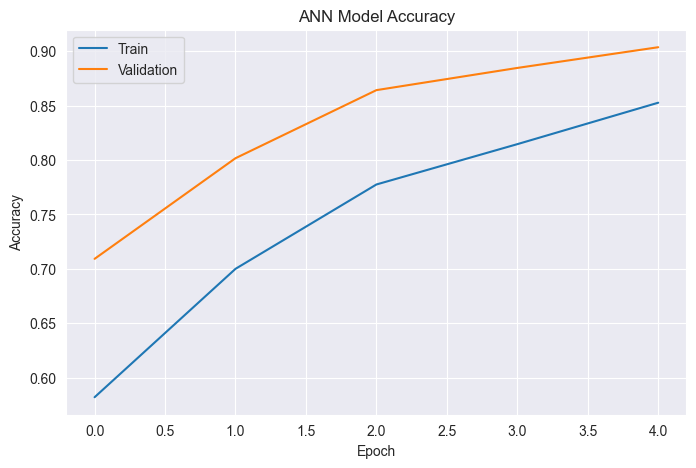

In [4]:
print("\n--- Step 6: Evaluation ---")
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# THE FIX: Flatten the predictions back to 1D for Scikit-Learn
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# We also flatten y_test just for the matrix comparison
y_test_flat = y_test.flatten()

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_flat, y_pred))

print("\nClassification Report:")
print(classification_report(y_test_flat, y_pred, target_names=['Not Spam', 'Spam']))

# Plotting Accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('ANN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()